# The Best Neighborhood in Pittsburgh

## Sub-Metric: Traffic Safety (Crash Data)

CMPINF 10/11 — Final Project (Notebook Created by Eldar Cakolli)

---

## 1. Introduction

A key part of determining the best neighborhood is traffic safety. Even if a neighborhood has low crime, high traffic accidents can still negatively impact quality of life through means of severe injury or death.

For this sub-metric, I am analyzing crash data in Allegheny County to determine which neighborhoods are the safest in terms of driving conditions and accident frequency. Fewer crashes indicate safer roads, better infrastructure, and reduced risk for residents and commuters.

My dataset spans from 2004-2024, providing a through report of traffic issues across Pittsburgh neighborhoods.

---

## 2. The Metric

### Datasets

Dataset 1: Cumulative Crash Data (Allegheny County)  
Dataset 2: Municipality Code 
Source: WPRDC
Coverage: 2004-2024

Each row represents a reported car crash in Pittsburgh.

---

### How I Calculate the Sub-Metric Score

Crash data does not directly include neighborhood names. Instead, it uses a municipality code.

So we:
1. Count crashes per municipality code
2. Match codes to actual neighborhood names using the code table
3. Convert codes into readable neighborhoods

The neighborhood with the lowest amount of car crashes is considered to have the best traffic safety and therefore ranks highest in this sub-metric. 

---

## 3. Analysis

### Setup and Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

crash = pd.read_csv("data/cumulativecrashdata.csv", low_memory=False)

municipality = pd.read_csv("data/municipalitycodes.csv")

print(crash.head())
print(municipality.head())

   _id   CRASH_CRN  DISTRICT  CRASH_COUNTY  MUNICIPALITY POLICE_AGCY  \
0    1  2004000001        11             2          2454       02454   
1    2  2004000010        11             2          2440       02440   
2    3  2004000016        11             2          2203       02203   
3    4  2004000022        11             2          2404       02404   
4    5  2004000030        11             2          2419       02419   

   CRASH_YEAR  CRASH_MONTH  DAY_OF_WEEK  TIME_OF_DAY  ...  LANE_COUNT  \
0        2004            1            5        257.0  ...         2.0   
1        2004            1            5       1027.0  ...         2.0   
2        2004            1            5       1839.0  ...         2.0   
3        2004            1            6        914.0  ...         2.0   
4        2004            1            5       2230.0  ...         2.0   

   RDWY_ORIENT  ROAD_OWNER  ROUTE  SPEED_LIMIT  SEGMENT  OFFSET  \
0            E         2.0   2032         35.0     10.0  1000

### Count Number of Crashes

In [9]:
crash_counts = crash['MUNICIPALITY'].value_counts().reset_index()
crash_counts.columns = ['Code', 'Crash Count']

crash_counts.head()

,Code,Crash Count
0,2301,85068
1,2113,8741
2,2446,8485
3,2116,6130
4,2473,5857


### Merge Codes with Neighborhoods, Crash Count Sorting and Table

In [8]:
merged = crash_counts.merge(municipality, on='Code', how='left')

merged = merged[['Municipality', 'Crash Count']].dropna()

merged = merged.sort_values('Crash Count', ascending=True)

pd.set_option('display.max_rows', None)

merged

,Municipality,Crash Count
129,Trafford Borough,2
127,South Versailles Township,6
126,Ben Avon Heights Borough,12
125,McDonald Borough,26
124,Reserve Township,29
123,Thornburg Borough,31
122,Chalfant Borough,44
121,Liberty Borough,53
120,Bradfordwoods Borough,58
119,Oakdale Borough,60


### Visualization

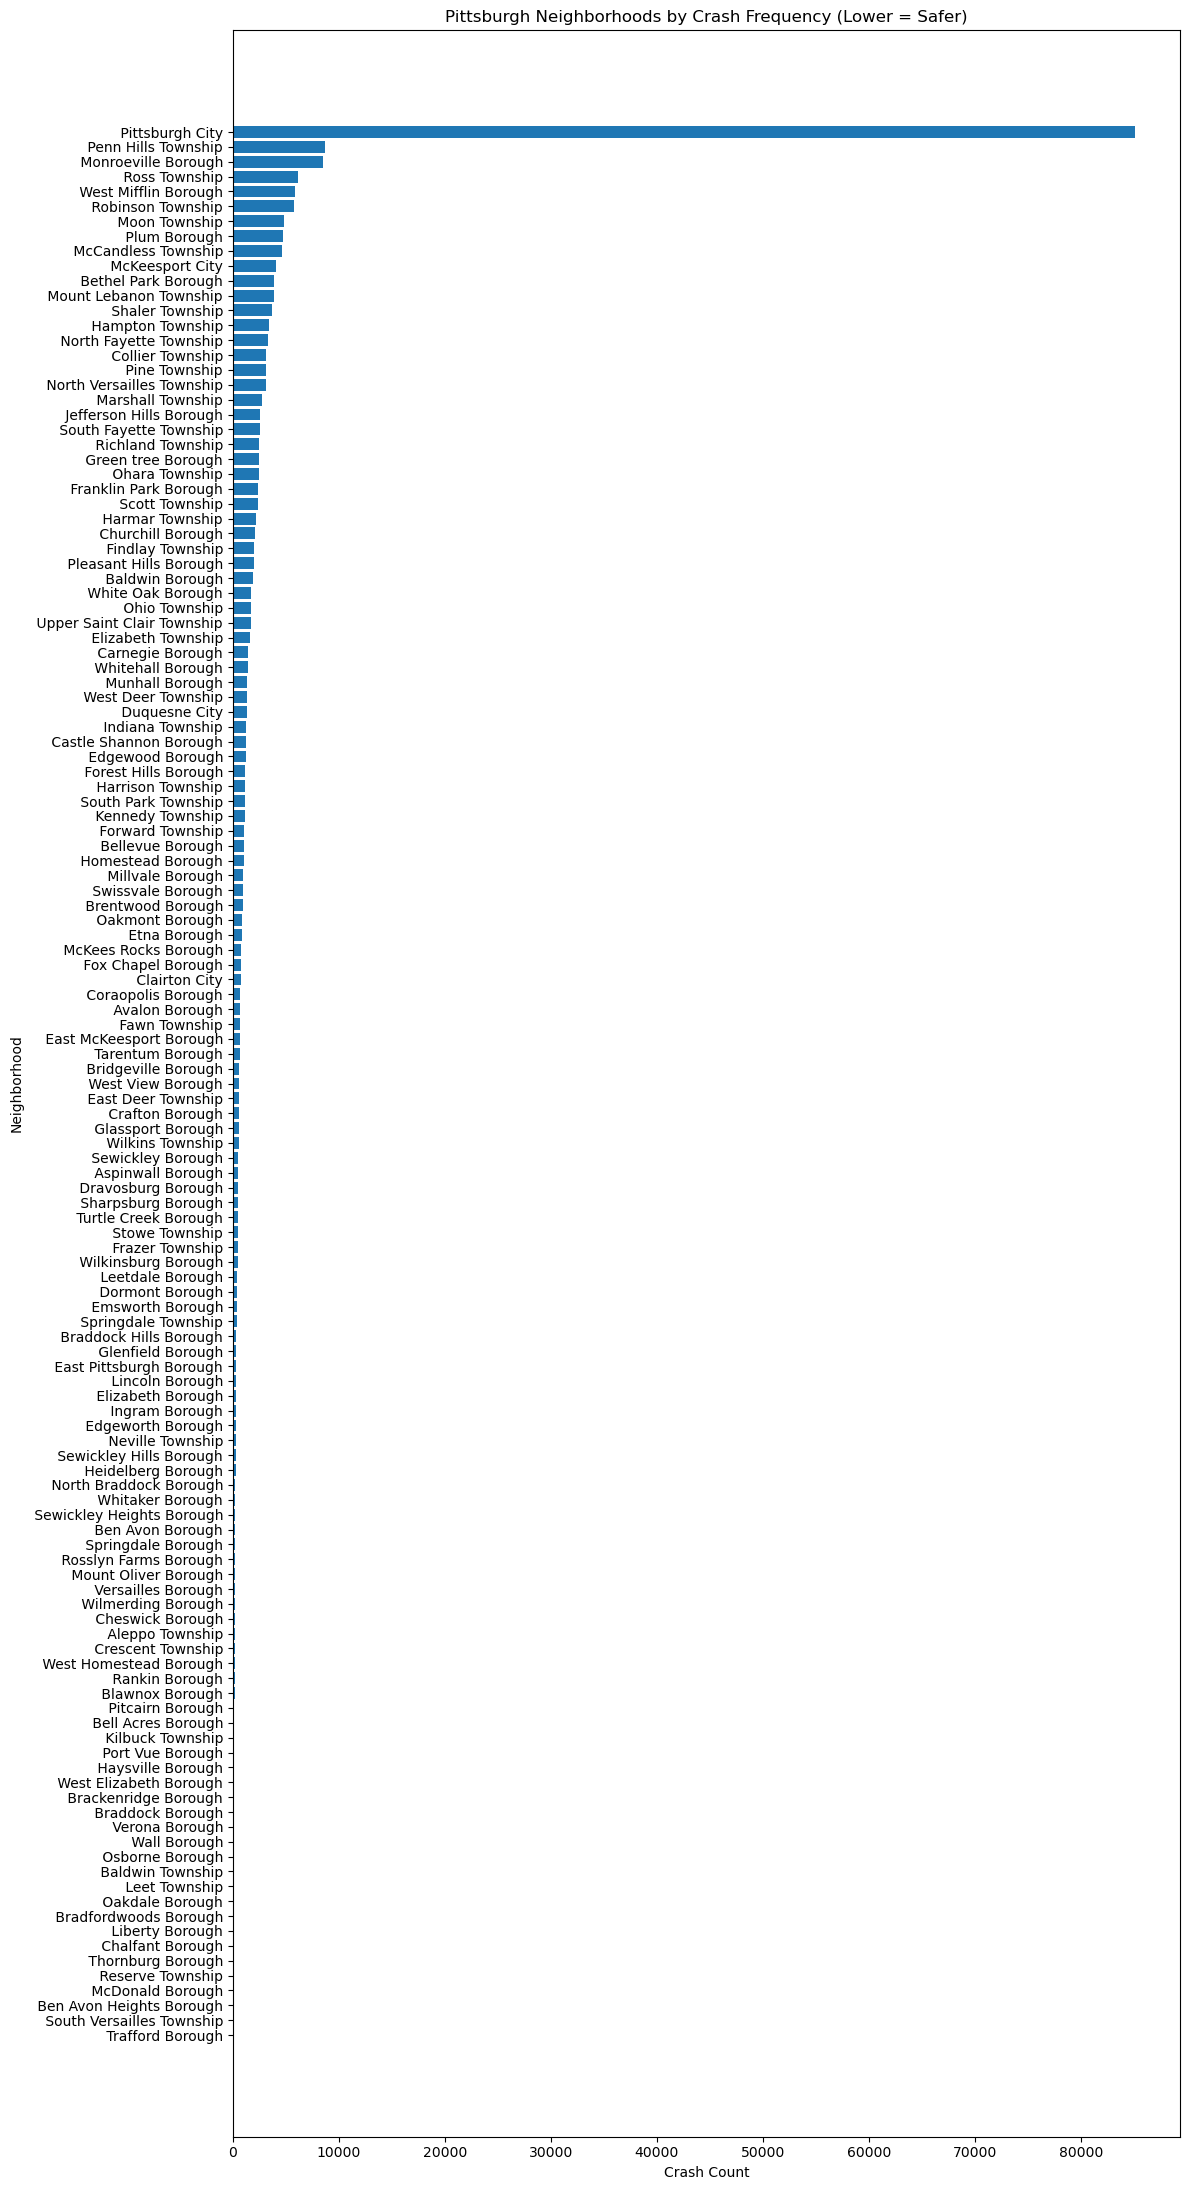

In [10]:
plt.figure(figsize=(12, 22))

plt.barh(merged['Municipality'], merged['Crash Count'])

plt.xlabel("Crash Count")
plt.ylabel("Neighborhood")
plt.title("Pittsburgh Neighborhoods by Crash Frequency (Lower = Safer)")

plt.tight_layout()
plt.show()

---

## 4. The Best Neighborhood — Crash Sub-Metric Result


In [11]:
best = merged.iloc[0]
worst = merged.iloc[-1]

print("BEST NEIGHBORHOOD (Crash Safety):")
print(best)

print("\nWORST NEIGHBORHOOD (Crash Safety):")
print(worst)

BEST NEIGHBORHOOD (Crash Safety):
Municipality     Trafford Borough
Crash Count                     2
Name: 129, dtype: object

WORST NEIGHBORHOOD (Crash Safety):
Municipality     Pittsburgh City
Crash Count                85068
Name: 0, dtype: object


Based on reported car crashes, Trafford Borough has the safest road conditions in Pittsburgh due to the lowest reported amount of car crashes. On the other hand, the most unsafe road conditions in Pittsburgh was Pittsburgh City because of the highest reported amount of car crashes. Neighborhoods with fewer crashes are considered safer for drivers, pedestrians, and residents, while neighborhoods with more crashes are considered dangerous for citizens. The results above rank neighborhoods based on the number of car crashes reflecting traffic safety.

---

## 5. Sub-Metric Score (for Group Combination)

To combine with other group members’ metrics, I normalize my results into a final score of the best.

For this sub-metric:
- Lower amounts of car crashes = better neighborhood
- These values will be used in the final group “best neighborhood” calculation


In [15]:
merged['Safety Score'] = 100 - (
    (merged['Crash Count'] - merged['Crash Count'].min()) /
    (merged['Crash Count'].max() - merged['Crash Count'].min()) * 100
)

crash_final = merged.sort_values('Safety Score', ascending=False)

crash_final

,Municipality,Crash Count,Safety Score
129,Trafford Borough,2,100.000000
127,South Versailles Township,6,99.995298
126,Ben Avon Heights Borough,12,99.988244
125,McDonald Borough,26,99.971787
124,Reserve Township,29,99.968260
123,Thornburg Borough,31,99.965909
122,Chalfant Borough,44,99.950627
121,Liberty Borough,53,99.940047
120,Bradfordwoods Borough,58,99.934169
119,Oakdale Borough,60,99.931818


---
## 6. Conclusion

This data shows the variation of road safety across Pittsburgh neighborhoods. Some areas experience fewer accidents ensuring their candidacy for the "best neighborhood" award, while other areas report larger amounts of accidents, removing them from the "best neighborhood" in Pittsburgh conversation. According to the data for this metric, Trafford Bourough was the "best" neighborhood in terms of traffic safety, while Pittsburgh Cith was the "worst" neighborhood due to its "poor" traffic safety score.

The results did shock me because I definitely was not expected Pittsburgh City and Penn Hills to be disproportionately high in comparison to other areas. I also find it interesting that the areas with DMV locations (Monroeville, Penn Hills, etc) had the highest amount of car crashes. Although I do not have an individual favorite area in Pittsburgh, the data inflicts ideas of the city being the worst area in Pittsburgh, despite it being one of my favorite 






